In [1]:
import torch
import datajoint as dj
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.prior_tables import FlowPriorConfig, AdaptPriorConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    FlowPriorResult,
    FPSamples,
    FPSamplesConfig,
    LikelihoodResult,
    MLPCondSamples,
    MLPCondSamplesConfig,
    SBVGPResult,
    SIResult,
    AdaptPriorResult,
)
from experiments.dj.evaluation_tables import SIEval, SBVGPEval
from experiments.dj.trainer_tables import (
    FPTrainerConfig,
    LLTrainerConfig,
    SBVGPTrainerConfig,
    SITrainerConfig,
    AdaptPriorTrainer
)
from experiments.dj.schema import schema
from experiments.dj.dj_helpers import drop_schema_dot_jobs
from experiments.dj.dj_helpers import fetch_best_model_results
from task_transfer.ml_lib.data_loading import build_dataloaders

[2024-07-16 14:13:55,961][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-16 14:13:57,206][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [3]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1
likelihood_config_proj_col = "ll_id"
best_val_likelihood_results = fetch_best_model_results(
    result_table=LikelihoodResult,
    config_table=LikelihoodConfig,
    data_loader_config_table=DataLoaderConfig,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)

restriction = (
    f"ll_id = '{best_val_likelihood_results['ll_id']}' "
    f"and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
)

LikelihoodResult & restriction

ll_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,125.39987182617188,1.1455481052398682,124.65189361572266,2.2731430530548096,124.65189361572266,2.2731430530548096,=BLOB=,=BLOB=,=BLOB=


In [15]:
FPTrainerConfig()

id,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
c40a50ce9c77369770dddd5129836477,0.001,0.001,600,128,10,10
f89651063b51487dcdf4041336ef89db,0.001,0.001,250,128,10,10


In [14]:
DataLoaderConfig()

id,data_fname,train_prop,val_prop
260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2
b8379e7d6998fc94a08a9a3742eec12d,/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl,0.7,0.2


In [2]:
FlowPriorResult()

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
0173a9aecec7a4e144011e0d3ff0c8a7,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.72239303588867,1.2013747692108154,-51.840248107910156,2.282120943069458,-51.840248107910156,2.282120943069458,=BLOB=,=BLOB=,=BLOB=
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.199527740478516,1.2041391134262085,-52.2991943359375,2.289771556854248,-52.2991943359375,2.289771556854248,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-72.07315826416016,1.3810926675796509,-71.84971618652344,2.6091067790985107,-71.84971618652344,2.6091067790985107,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-72.36489868164062,1.463006615638733,-72.16575622558594,2.690886974334717,-72.16575622558594,2.690886974334717,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-126.7267837524414,1.5894485712051392,-126.70783996582031,2.9417123794555664,-126.70783996582031,2.9417123794555664,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-74.34554290771484,1.4281342029571533,-74.0283432006836,2.6899912357330322,-74.0283432006836,2.6899912357330322,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-71.88994598388672,1.4057899713516235,-71.6804428100586,2.6343274116516113,-71.6804428100586,2.6343274116516113,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-55.91200256347656,1.221100091934204,-56.58893966674805,2.382314443588257,-56.58893966674805,2.382314443588257,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-5981.26806640625,212.3249969482422,-6216.796875,713.691162109375,-6216.796875,713.691162109375,=BLOB=,=BLOB=,=BLOB=


In [2]:
LikelihoodResult()

ll_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
44a8edea52d1adc36a06935005d2faa7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,125.74639129638672,1.1399195194244385,124.45130157470703,2.2416083812713623,124.45130157470703,2.2416083812713623,=BLOB=,=BLOB=,=BLOB=
a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,125.39987182617188,1.1455481052398682,124.65189361572266,2.2731430530548096,124.65189361572266,2.2731430530548096,=BLOB=,=BLOB=,=BLOB=


In [3]:
FlowPriorResult()

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
0173a9aecec7a4e144011e0d3ff0c8a7,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.72239303588867,1.2013747692108154,-51.840248107910156,2.282120943069458,-51.840248107910156,2.282120943069458,=BLOB=,=BLOB=,=BLOB=
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.199527740478516,1.2041391134262085,-52.2991943359375,2.289771556854248,-52.2991943359375,2.289771556854248,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-72.07315826416016,1.3810926675796509,-71.84971618652344,2.6091067790985107,-71.84971618652344,2.6091067790985107,=BLOB=,=BLOB=,=BLOB=
036827f08f256e836cacde3d2954ea4a,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-72.36489868164062,1.463006615638733,-72.16575622558594,2.690886974334717,-72.16575622558594,2.690886974334717,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-126.7267837524414,1.5894485712051392,-126.70783996582031,2.9417123794555664,-126.70783996582031,2.9417123794555664,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-74.34554290771484,1.4281342029571533,-74.0283432006836,2.6899912357330322,-74.0283432006836,2.6899912357330322,=BLOB=,=BLOB=,=BLOB=
06bb4905529cab2d09a6b5fb479cd700,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-71.88994598388672,1.4057899713516235,-71.6804428100586,2.6343274116516113,-71.6804428100586,2.6343274116516113,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-55.91200256347656,1.221100091934204,-56.58893966674805,2.382314443588257,-56.58893966674805,2.382314443588257,=BLOB=,=BLOB=,=BLOB=
06fe441dd0fdca3ae7bfa7a4ad856467,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-5981.26806640625,212.3249969482422,-6216.796875,713.691162109375,-6216.796875,713.691162109375,=BLOB=,=BLOB=,=BLOB=


In [4]:
FlowPriorConfig()

id,seed,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type
0173a9aecec7a4e144011e0d3ff0c8a7,42,2,inv_softplus,none,tanh,normal,full
036827f08f256e836cacde3d2954ea4a,42,3,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,factorized
0626e82eec85ade7041703d85e168d5b,42,3,inv_softplus,none,leaky_relu,normal,factorized
06bb4905529cab2d09a6b5fb479cd700,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,factorized
06fe441dd0fdca3ae7bfa7a4ad856467,100,2,inv_softplus,none,tanh,lowrank_multivariate_normal_10,full
0ca2aadbd204c4e82604881cb610f139,100,3,inv_softplus,none,leaky_relu,normal,full
0eada7f45a684dde102302a582613e97,42,3,inv_softplus,none,tanh,lowrank_multivariate_normal_1,full
11d2ee8d603323c521cbcdaac3a7da19,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,full
16901c461ff0ccf8f2b5e22bcba8899c,100,2,inv_softplus,none,tanh,normal,full
16f5b801b61df75d6f7f136ef8910b32,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_10,full


In [5]:
FPTrainerConfig()

id,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
c40a50ce9c77369770dddd5129836477,0.001,0.001,600,128,10,10
f89651063b51487dcdf4041336ef89db,0.001,0.001,250,128,10,10


In [4]:
DataLoaderConfig()

id,data_fname,train_prop,val_prop
260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2


In [3]:
AdaptPriorResult.key_source

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,260a5ea8175f75eaef132f42873ad14a
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,260a5ea8175f75eaef132f42873ad14a
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,9ef3ae6fea33eba634d928a88b866836
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,260a5ea8175f75eaef132f42873ad14a
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,260a5ea8175f75eaef132f42873ad14a
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,9ef3ae6fea33eba634d928a88b866836
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,6a40e4f70ae9e60ad158a5da6db1661d,260a5ea8175f75eaef132f42873ad14a
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,260a5ea8175f75eaef132f42873ad14a


In [3]:
AdaptPriorTrainer()

id,mc_sample_size,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
6a40e4f70ae9e60ad158a5da6db1661d,100,0.001,0.001,300,128,1000,1000
e267b2071bca2c3f9431f155e8e58f23,50000,0.001,0.001,300,128,1000,1000


In [11]:
AdaptPriorResult.key_source

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836
42,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836
100,d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,e267b2071bca2c3f9431f155e8e58f23,9ef3ae6fea33eba634d928a88b866836


In [5]:
FlowPriorConfig()

[2024-07-02 13:29:06,826][WARNING]: MySQL server has gone away. Reconnecting to the server.


id,seed,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type
0173a9aecec7a4e144011e0d3ff0c8a7,42,2,inv_softplus,none,tanh,normal,full
036827f08f256e836cacde3d2954ea4a,42,3,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,factorized
0626e82eec85ade7041703d85e168d5b,42,3,inv_softplus,none,leaky_relu,normal,factorized
06bb4905529cab2d09a6b5fb479cd700,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,factorized
06fe441dd0fdca3ae7bfa7a4ad856467,100,2,inv_softplus,none,tanh,lowrank_multivariate_normal_10,full
0ca2aadbd204c4e82604881cb610f139,100,3,inv_softplus,none,leaky_relu,normal,full
0eada7f45a684dde102302a582613e97,42,3,inv_softplus,none,tanh,lowrank_multivariate_normal_1,full
11d2ee8d603323c521cbcdaac3a7da19,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_2,full
16901c461ff0ccf8f2b5e22bcba8899c,100,2,inv_softplus,none,tanh,normal,full
16f5b801b61df75d6f7f136ef8910b32,42,2,inv_softplus,none,leaky_relu,lowrank_multivariate_normal_10,full


In [12]:
no_corr_restriction = "flow_base_dist = 'normal' and affine_type = 'factorized'"
FlowPriorConfig & no_corr_restriction

id,seed,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type
0626e82eec85ade7041703d85e168d5b,42,3,inv_softplus,none,leaky_relu,normal,factorized
474d2c24ed78a9bb4a22f29f0808468e,42,2,inv_softplus,none,leaky_relu,normal,factorized
487c591ff55ca28abc4c4126d0c5e484,100,2,inv_softplus,none,tanh,normal,factorized
5e738abbecc2e0e4925c7778036a1aa7,100,3,inv_softplus,none,leaky_relu,normal,factorized
d0cf491f03b7f839c8a54834a6168081,42,2,inv_softplus,none,tanh,normal,factorized
ed7269c2e65f26b97f5fc6031445ccd6,100,2,inv_softplus,none,leaky_relu,normal,factorized
f14ea0efe1d84f1008c1b452ec9cdc2a,100,3,inv_softplus,none,tanh,normal,factorized
fd41e0ac4ce4840783241091705b56c1,42,3,inv_softplus,none,tanh,normal,factorized


In [6]:
AdaptPriorResult.key_source

seed,prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,a7e83afb3d10e49d76cbfbe16c294932,9ef3ae6fea33eba634d928a88b866836
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,a7e83afb3d10e49d76cbfbe16c294932,9ef3ae6fea33eba634d928a88b866836
42,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,b4400f97d2c4a40c100d69b05687bac2,9ef3ae6fea33eba634d928a88b866836
100,89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,b4400f97d2c4a40c100d69b05687bac2,9ef3ae6fea33eba634d928a88b866836


In [6]:
AdaptPriorConfig()

prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training
89c1053a65023b042dc63f7f852bb5b0,f89651063b51487dcdf4041336ef89db,a67b8eaff13e89e7272e90768c2ab280,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a


In [7]:
AdaptPriorTrainer()

id,mc_sample_size,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
06c83f67013412db5f3dfee70700642e,10,0.001,0.001,250,128,10,10
147cb623e6f58a8a13f8411b0342fb62,100,0.001,0.001,250,128,10,10
638897710ee7c79594d5984237a48e7b,1,0.001,0.001,250,128,10,10


In [2]:
AdaptPriorResult()

prior_fp_id to index into FlowPriorConfig,prior_trainer_id to index into FPTrainerConfig,likelihood_id to index into LikelihoodConfig,likelihood_trainer_id to index into LLTrainerConfig,orig_dl_id to index into DataLoaderConfig used for the prior and likelihood training,trainer_id,dl_id,"train_marginal_obs_ll_mean mean per trial, per sample, in nats",train_marginal_obs_ll_sem standard error of the mean,val_marginal_obs_ll_mean,val_marginal_obs_ll_sem,test_marginal_obs_ll_mean,test_marginal_obs_ll_sem,"train_prior_ll_mean mean per trial, per sample, in nats",train_prior_ll_sem standard error of the mean,val_prior_ll_mean,val_prior_ll_sem,test_prior_ll_mean,test_prior_ll_sem,tracker_output,eval_output,model trained joint model NOT just the prior


In [6]:
best_si = SIResult.fetch(download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True)[0]

In [7]:
best_si

{'si_id': '6deb07682dd4919b2ebe01c255b23445',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -41.92620086669922,
 'train_ll_sem': 1.1980952024459839,
 'val_ll_mean': -42.170867919921875,
 'val_ll_sem': 2.237703561782837,
 'test_ll_mean': -42.587188720703125,
 'test_ll_sem': 3.137392282485962,
 'tracker_output': '/tmp/b5e3fc198eeb85e50e40b8bcbdf52c03_tracker_output.pkl',
 'eval_output': '/tmp/b5e3fc198eeb85e50e40b8bcbdf52c03_eval_output.pkl',
 'model': '/tmp/b5e3fc198eeb85e50e40b8bcbdf52c03_model.pt'}

In [11]:
SIEval & "si_id = '6deb07682dd4919b2ebe01c255b23445'"

si_id,trainer_id,dl_id,data_fname,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem
6deb07682dd4919b2ebe01c255b23445,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-41.95217514038086,1.206075668334961,-42.19430160522461,2.2373244762420654,-42.50288772583008,3.1013448238372803


In [12]:
best_sb = SBVGPResult.fetch(download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True)[0]

In [13]:
best_sb

{'sbvp_id': '77941396a735dc6ee02bcdf4b24896e7',
 'sbvp_trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'fp_samples_id': '89c1053a65023b042dc63f7f852bb5b0',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'trainer_id': 'f89651063b51487dcdf4041336ef89db',
 'data_seed': 42,
 'n_samples': 10000,
 'mlpcond_samples_id': 'a67b8eaff13e89e7272e90768c2ab280',
 'train_ll_mean': -42.586299896240234,
 'train_ll_sem': 1.2058463096618652,
 'val_ll_mean': -42.43896484375,
 'val_ll_sem': 2.2401511669158936,
 'test_ll_mean': -42.79315948486328,
 'test_ll_sem': 3.1141483783721924,
 'train_ll_mean_sample': -42.623722076416016,
 'train_ll_sem_sample': 1.23116135597229,
 'val_ll_mean_sample': -43.50209045410156,
 'val_ll_sem_sample': 2.835571765899658,
 'test_ll_mean_sample': -43.38511276245117,
 'test_ll_sem_sample': 3.8856871128082275,
 'tracker_output': '/tmp/19f7ec58c32423cc3c752c06de023ae1_tracker_output.pkl',
 'eval_output': '/tmp/19f7ec58c32423cc3c752c06de023ae1_eval_output.pkl',
 'model': '/tmp/19f

In [15]:
SBVGPEval & "sbvp_id = '77941396a735dc6ee02bcdf4b24896e7'"

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,data_fname,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem
77941396a735dc6ee02bcdf4b24896e7,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.56834411621094,1.2101439237594604,-42.45597839355469,2.231565237045288,-42.71959686279297,3.087824583053589


In [4]:
SIResult()

si_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
39f03eac90b439e7897b6f4a65464417,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-41.9784049987793,1.2008603811264038,-42.252342224121094,2.2518041133880615,-42.61870193481445,3.1429383754730225,=BLOB=,=BLOB=,=BLOB=
45f442bf0f2c1dcfb984300f172610bf,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.232418060302734,1.1933763027191162,-42.48735809326172,2.243901014328003,-42.891815185546875,3.142155170440674,=BLOB=,=BLOB=,=BLOB=
4babfd012e0443ef1ae2139deb4def7b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.910369873046875,1.1807067394256592,-43.04535675048828,2.2083466053009033,-43.36171340942383,3.089459180831909,=BLOB=,=BLOB=,=BLOB=
5531fc5da506b401bcdb7f43e282f731,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.95983123779297,1.1811304092407227,-43.03318786621094,2.2080531120300293,-43.36014938354492,3.083613157272339,=BLOB=,=BLOB=,=BLOB=
5c533709d4d10462567539f3529e43b4,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.945709228515625,1.1790655851364136,-43.054447174072266,2.2038252353668213,-43.395957946777344,3.0836145877838135,=BLOB=,=BLOB=,=BLOB=
6deb07682dd4919b2ebe01c255b23445,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-41.92620086669922,1.1980952024459839,-42.170867919921875,2.237703561782837,-42.587188720703125,3.137392282485962,=BLOB=,=BLOB=,=BLOB=
8352064bedbeed787d946629a6e80649,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.20967483520508,1.191443681716919,-42.495506286621094,2.2505924701690674,-42.844547271728516,3.14346981048584,=BLOB=,=BLOB=,=BLOB=
841daafa5d8da9165d3677d09f28bf56,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.93891143798828,1.1815905570983887,-43.05723571777344,2.2125537395477295,-43.3827018737793,3.0836896896362305,=BLOB=,=BLOB=,=BLOB=
8c7c772c5d9577f0dbe5adae2487a504,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.24616241455078,1.1930749416351318,-42.483943939208984,2.2454216480255127,-42.832801818847656,3.123835563659668,=BLOB=,=BLOB=,=BLOB=
9f184ea53fc4c7c50e794aa0441e8dba,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.958858489990234,1.1824500560760498,-43.05030059814453,2.2079660892486572,-43.369483947753906,3.0924909114837646,=BLOB=,=BLOB=,=BLOB=


In [2]:
SIEval()

si_id,trainer_id,dl_id,data_fname,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem
39f03eac90b439e7897b6f4a65464417,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.0063362121582,1.2096346616744995,-42.262062072753906,2.2472386360168457,-42.54438400268555,3.111186981201172
45f442bf0f2c1dcfb984300f172610bf,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.257259368896484,1.2022645473480225,-42.51462936401367,2.2392117977142334,-42.80945587158203,3.1096510887145996
4babfd012e0443ef1ae2139deb4def7b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.9190788269043,1.187865138053894,-43.04915237426758,2.197420597076416,-43.27688217163086,3.067519187927246
5531fc5da506b401bcdb7f43e282f731,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.9693489074707,1.1889492273330688,-43.04359817504883,2.1999154090881348,-43.2767448425293,3.0630130767822266
5c533709d4d10462567539f3529e43b4,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.952911376953125,1.1864980459213257,-43.054168701171875,2.189534902572632,-43.315731048583984,3.063152313232422
6deb07682dd4919b2ebe01c255b23445,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-41.95217514038086,1.206075668334961,-42.19430160522461,2.2373244762420654,-42.50288772583008,3.1013448238372803
8352064bedbeed787d946629a6e80649,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.232574462890625,1.2004494667053223,-42.49634552001953,2.2363743782043457,-42.75817108154297,3.1012282371520996
841daafa5d8da9165d3677d09f28bf56,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.94599151611328,1.1886340379714966,-43.051719665527344,2.1966733932495117,-43.30424880981445,3.064600944519043
8c7c772c5d9577f0dbe5adae2487a504,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.26594543457031,1.202166199684143,-42.48448181152344,2.232003688812256,-42.747154235839844,3.0807061195373535
9f184ea53fc4c7c50e794aa0441e8dba,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.96413040161133,1.1891939640045166,-43.05480194091797,2.1971852779388428,-43.28512191772461,3.067314386367798


In [3]:
SBVGPEval()

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,data_fname,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem
1ac2319597086135f22adbdd15a1f825,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.63404083251953,1.2062275409698486,-42.55239486694336,2.2415647506713867,-42.83564758300781,3.087120771408081
36eab0ea230ede206a2a59c247c98371,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-44.91911315917969,1.1892952919006348,-44.771156311035156,2.1848552227020264,-45.01365280151367,3.042677164077759
562d53011645a0ef829bb37611ccaee0,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.72737503051758,1.2086377143859863,-42.61026382446289,2.224555492401123,-42.864097595214844,3.0792646408081055
5e13a9ae52b31a3bc9aa3ba9ccbea6f8,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.63764190673828,1.2103885412216187,-42.51335525512695,2.2207655906677246,-42.77631378173828,3.0718679428100586
68d8b67fc4279c76e4f84534ef2a4612,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-44.897186279296875,1.1318165063858032,-44.73918914794922,2.0859456062316895,-45.019779205322266,2.8971433639526367
77941396a735dc6ee02bcdf4b24896e7,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.56834411621094,1.2101439237594604,-42.45597839355469,2.231565237045288,-42.71959686279297,3.087824583053589
7d73a903878502a5f79755d21947b028,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.63404083251953,1.2062275409698486,-42.55239486694336,2.2415647506713867,-42.83564758300781,3.087120771408081
819b69c0604c8adf3f9c9623f4aae692,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-42.72737503051758,1.2086377143859863,-42.61026382446289,2.224555492401123,-42.864097595214844,3.0792646408081055
9248e70409454ae5d5ce4cbe063560b6,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_2_dataset.pkl,-44.49808883666992,1.1458896398544312,-44.364410400390625,2.11948561668396,-44.59071731567383,2.926140546798706
92

In [5]:
SBVGPResult()

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,"train_ll_mean_sample mean per dimension, per sample, in nats",train_ll_sem_sample standard error of the mean,val_ll_mean_sample,val_ll_sem_sample,test_ll_mean_sample,test_ll_sem_sample,tracker_output,eval_output,model
1ac2319597086135f22adbdd15a1f825,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
36eab0ea230ede206a2a59c247c98371,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.93428421020508,1.1843044757843018,-44.774078369140625,2.1995482444763184,-45.10660934448242,3.0413012504577637,-45.80355453491211,1.3658243417739868,-46.07779312133789,2.656816244125366,-45.90259552001953,3.846435070037842,=BLOB=,=BLOB=,=BLOB=
562d53011645a0ef829bb37611ccaee0,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.2029000520706177,-42.57764434814453,2.2273013591766357,-42.96065139770508,3.1034605503082275,-42.85182189941406,1.2442842721939087,-43.60990905761719,2.5732622146606445,-43.518531799316406,3.7830400466918945,=BLOB=,=BLOB=,=BLOB=
5e13a9ae52b31a3bc9aa3ba9ccbea6f8,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.64146423339844,1.204351782798767,-42.48711395263672,2.231215000152588,-42.88119888305664,3.1041481494903564,-42.75542068481445,1.2373509407043457,-43.5567741394043,2.627535104751587,-43.41323471069336,3.81445050239563,=BLOB=,=BLOB=,=BLOB=
68d8b67fc4279c76e4f84534ef2a4612,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.906986236572266,1.1276683807373047,-44.73395538330078,2.097158670425415,-45.095584869384766,2.8986129760742188,-45.790557861328125,1.3504111766815186,-46.13823699951172,2.95158314704895,-46.06719207763672,4.1725873947143555,=BLOB=,=BLOB=,=BLOB=
77941396a735dc6ee02bcdf4b24896e7,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.586299896240234,1.2058463096618652,-42.43896484375,2.2401511669158936,-42.79315948486328,3.1141483783721924,-42.623722076416016,1.23116135597229,-43.50209045410156,2.835571765899658,-43.38511276245117,3.8856871128082275,=BLOB=,=BLOB=,=BLOB=
7d73a903878502a5f79755d21947b028,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
819b69c0604c8adf3f9c9623f4aae692,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.202900052

In [4]:
# drop_schema_dot_jobs(schema)

[2024-06-13 15:54:06,421][INFO]: Dropped table `sshrinivasan_task_transfer`.`~jobs`


In [2]:
# SIResult.drop()
# SITrainerConfig.drop()
# SIConfig.drop()

[2024-06-13 15:33:25,117][INFO]: `sshrinivasan_task_transfer`.`__s_i_result` (0 tuples)
[2024-06-13 15:33:26,405][INFO]: Dropped table `sshrinivasan_task_transfer`.`__s_i_result`
[2024-06-13 15:33:26,484][INFO]: Tables dropped. Restart kernel.
[2024-06-13 15:33:26,576][INFO]: `sshrinivasan_task_transfer`.`s_i_trainer_config` (1 tuples)
[2024-06-13 15:33:27,351][INFO]: Dropped table `sshrinivasan_task_transfer`.`s_i_trainer_config`
[2024-06-13 15:33:27,430][INFO]: Tables dropped. Restart kernel.
[2024-06-13 15:33:27,521][INFO]: `sshrinivasan_task_transfer`.`s_i_config` (12 tuples)
[2024-06-13 15:33:28,262][INFO]: Dropped table `sshrinivasan_task_transfer`.`s_i_config`
[2024-06-13 15:33:28,341][INFO]: Tables dropped. Restart kernel.


In [5]:
SBVGPResult()

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,"train_ll_mean_sample mean per dimension, per sample, in nats",train_ll_sem_sample standard error of the mean,val_ll_mean_sample,val_ll_sem_sample,test_ll_mean_sample,test_ll_sem_sample,tracker_output,eval_output,model
1ac2319597086135f22adbdd15a1f825,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
36eab0ea230ede206a2a59c247c98371,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.93428421020508,1.1843044757843018,-44.774078369140625,2.1995482444763184,-45.10660934448242,3.0413012504577637,-45.80355453491211,1.3658243417739868,-46.07779312133789,2.656816244125366,-45.90259552001953,3.846435070037842,=BLOB=,=BLOB=,=BLOB=
562d53011645a0ef829bb37611ccaee0,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.2029000520706177,-42.57764434814453,2.2273013591766357,-42.96065139770508,3.1034605503082275,-42.85182189941406,1.2442842721939087,-43.60990905761719,2.5732622146606445,-43.518531799316406,3.7830400466918945,=BLOB=,=BLOB=,=BLOB=
5e13a9ae52b31a3bc9aa3ba9ccbea6f8,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.64146423339844,1.204351782798767,-42.48711395263672,2.231215000152588,-42.88119888305664,3.1041481494903564,-42.75542068481445,1.2373509407043457,-43.5567741394043,2.627535104751587,-43.41323471069336,3.81445050239563,=BLOB=,=BLOB=,=BLOB=
68d8b67fc4279c76e4f84534ef2a4612,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.906986236572266,1.1276683807373047,-44.73395538330078,2.097158670425415,-45.095584869384766,2.8986129760742188,-45.790557861328125,1.3504111766815186,-46.13823699951172,2.95158314704895,-46.06719207763672,4.1725873947143555,=BLOB=,=BLOB=,=BLOB=
77941396a735dc6ee02bcdf4b24896e7,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.586299896240234,1.2058463096618652,-42.43896484375,2.2401511669158936,-42.79315948486328,3.1141483783721924,-42.623722076416016,1.23116135597229,-43.50209045410156,2.835571765899658,-43.38511276245117,3.8856871128082275,=BLOB=,=BLOB=,=BLOB=
7d73a903878502a5f79755d21947b028,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
819b69c0604c8adf3f9c9623f4aae692,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.202900052

In [37]:
schema.jobs

table_name className of the table,key_hash key hash,"status if tuple is missing, the job is available",key structure containing the key,error_message error message returned if failed,error_stack error stack if failed,user database user,host system hostname,pid system process id,connection_id connection_id(),timestamp automatic timestamp


In [2]:
# drop_schema_dot_jobs(schema)

[2024-06-13 13:22:39,085][INFO]: Dropped table `sshrinivasan_task_transfer`.`~jobs`


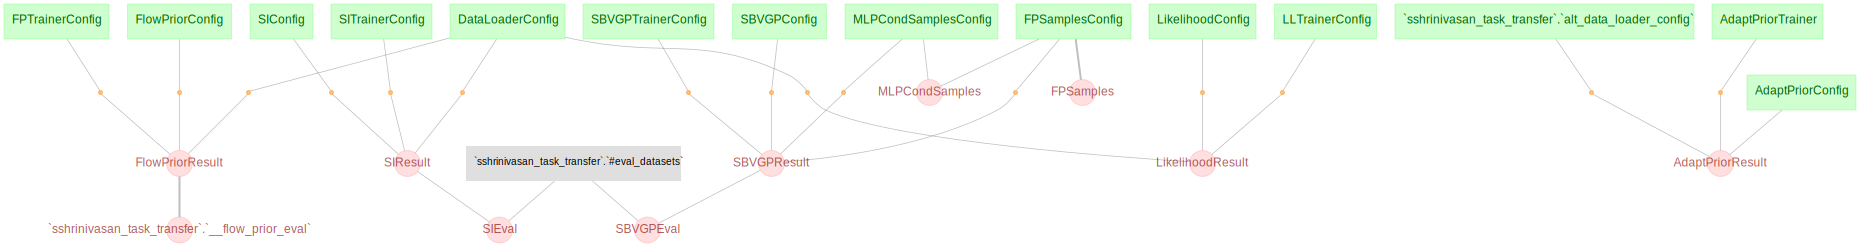

In [2]:
dj.Diagram(schema)

In [2]:
SIResult()

si_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
39f03eac90b439e7897b6f4a65464417,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-41.9784049987793,1.2008603811264038,-42.252342224121094,2.2518041133880615,-42.61870193481445,3.1429383754730225,=BLOB=,=BLOB=,=BLOB=
45f442bf0f2c1dcfb984300f172610bf,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.232418060302734,1.1933763027191162,-42.48735809326172,2.243901014328003,-42.891815185546875,3.142155170440674,=BLOB=,=BLOB=,=BLOB=
4babfd012e0443ef1ae2139deb4def7b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.910369873046875,1.1807067394256592,-43.04535675048828,2.2083466053009033,-43.36171340942383,3.089459180831909,=BLOB=,=BLOB=,=BLOB=
5531fc5da506b401bcdb7f43e282f731,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.95983123779297,1.1811304092407227,-43.03318786621094,2.2080531120300293,-43.36014938354492,3.083613157272339,=BLOB=,=BLOB=,=BLOB=
5c533709d4d10462567539f3529e43b4,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.945709228515625,1.1790655851364136,-43.054447174072266,2.2038252353668213,-43.395957946777344,3.0836145877838135,=BLOB=,=BLOB=,=BLOB=
6deb07682dd4919b2ebe01c255b23445,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-41.92620086669922,1.1980952024459839,-42.170867919921875,2.237703561782837,-42.587188720703125,3.137392282485962,=BLOB=,=BLOB=,=BLOB=
8352064bedbeed787d946629a6e80649,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.20967483520508,1.191443681716919,-42.495506286621094,2.2505924701690674,-42.844547271728516,3.14346981048584,=BLOB=,=BLOB=,=BLOB=
841daafa5d8da9165d3677d09f28bf56,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.93891143798828,1.1815905570983887,-43.05723571777344,2.2125537395477295,-43.3827018737793,3.0836896896362305,=BLOB=,=BLOB=,=BLOB=
8c7c772c5d9577f0dbe5adae2487a504,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.24616241455078,1.1930749416351318,-42.483943939208984,2.2454216480255127,-42.832801818847656,3.123835563659668,=BLOB=,=BLOB=,=BLOB=
9f184ea53fc4c7c50e794aa0441e8dba,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-42.958858489990234,1.1824500560760498,-43.05030059814453,2.2079660892486572,-43.369483947753906,3.0924909114837646,=BLOB=,=BLOB=,=BLOB=


In [3]:
SBVGPResult()

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,"train_ll_mean_sample mean per dimension, per sample, in nats",train_ll_sem_sample standard error of the mean,val_ll_mean_sample,val_ll_sem_sample,test_ll_mean_sample,test_ll_sem_sample,tracker_output,eval_output,model
1ac2319597086135f22adbdd15a1f825,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
36eab0ea230ede206a2a59c247c98371,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.93428421020508,1.1843044757843018,-44.774078369140625,2.1995482444763184,-45.10660934448242,3.0413012504577637,-45.80355453491211,1.3658243417739868,-46.07779312133789,2.656816244125366,-45.90259552001953,3.846435070037842,=BLOB=,=BLOB=,=BLOB=
562d53011645a0ef829bb37611ccaee0,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.2029000520706177,-42.57764434814453,2.2273013591766357,-42.96065139770508,3.1034605503082275,-42.85182189941406,1.2442842721939087,-43.60990905761719,2.5732622146606445,-43.518531799316406,3.7830400466918945,=BLOB=,=BLOB=,=BLOB=
5e13a9ae52b31a3bc9aa3ba9ccbea6f8,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.64146423339844,1.204351782798767,-42.48711395263672,2.231215000152588,-42.88119888305664,3.1041481494903564,-42.75542068481445,1.2373509407043457,-43.5567741394043,2.627535104751587,-43.41323471069336,3.81445050239563,=BLOB=,=BLOB=,=BLOB=
68d8b67fc4279c76e4f84534ef2a4612,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-44.906986236572266,1.1276683807373047,-44.73395538330078,2.097158670425415,-45.095584869384766,2.8986129760742188,-45.790557861328125,1.3504111766815186,-46.13823699951172,2.95158314704895,-46.06719207763672,4.1725873947143555,=BLOB=,=BLOB=,=BLOB=
77941396a735dc6ee02bcdf4b24896e7,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.586299896240234,1.2058463096618652,-42.43896484375,2.2401511669158936,-42.79315948486328,3.1141483783721924,-42.623722076416016,1.23116135597229,-43.50209045410156,2.835571765899658,-43.38511276245117,3.8856871128082275,=BLOB=,=BLOB=,=BLOB=
7d73a903878502a5f79755d21947b028,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.6478271484375,1.2008092403411865,-42.51524353027344,2.243183135986328,-42.936038970947266,3.121626138687134,-42.745079040527344,1.2337504625320435,-43.62240219116211,2.930140972137451,-43.407901763916016,3.6811320781707764,=BLOB=,=BLOB=,=BLOB=
819b69c0604c8adf3f9c9623f4aae692,f89651063b51487dcdf4041336ef89db,89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000,a67b8eaff13e89e7272e90768c2ab280,-42.74100875854492,1.202900052

In [12]:
SBVGPConfig.proj(sbvp_id="id")

sbvp_id
1ac2319597086135f22adbdd15a1f825
36eab0ea230ede206a2a59c247c98371
562d53011645a0ef829bb37611ccaee0
5e13a9ae52b31a3bc9aa3ba9ccbea6f8
68d8b67fc4279c76e4f84534ef2a4612
77941396a735dc6ee02bcdf4b24896e7
7d73a903878502a5f79755d21947b028
819b69c0604c8adf3f9c9623f4aae692
9248e70409454ae5d5ce4cbe063560b6
92f77b578048eae8738857f5730e378a


In [25]:
SBVGPTrainerConfig.proj(trainer_id="id")

trainer_id
64276dc6f2dd44d5cc4f3e954ab8e67c


In [26]:
FPSamplesConfig.proj(fp_samples_id="fp_id", data_seed="seed")

fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples
89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,10000


In [27]:
MLPCondSamplesConfig.proj(mlpcond_samples_id="ll_id")

mlpcond_samples_id from LikelihoodResult
a67b8eaff13e89e7272e90768c2ab280


In [29]:
SBVGPResult()

sbvp_id,trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,"train_ll_mean_sample mean per dimension, per sample, in nats",train_ll_sem_sample standard error of the mean,val_ll_mean_sample,val_ll_sem_sample,test_ll_mean_sample,test_ll_sem_sample,tracker_output,eval_output,model


In [3]:
# FPSamples.drop()
# MLPCondSamples.drop()
# SBVGPResult.drop()
# SBVGPTrainerConfig.drop()
# FPSamplesConfig.drop()
# MLPCondSamplesConfig.drop()
# SBVGPConfig.drop()

[2024-06-13 13:22:44,894][INFO]: `sshrinivasan_task_transfer`.`__f_p_samples` (1 tuples)
[2024-06-13 13:22:46,556][INFO]: Dropped table `sshrinivasan_task_transfer`.`__f_p_samples`
[2024-06-13 13:22:46,632][INFO]: Tables dropped. Restart kernel.
[2024-06-13 13:22:46,741][INFO]: `sshrinivasan_task_transfer`.`__m_l_p_cond_samples` (1 tuples)
[2024-06-13 13:22:47,464][INFO]: Dropped table `sshrinivasan_task_transfer`.`__m_l_p_cond_samples`
[2024-06-13 13:22:47,540][INFO]: Tables dropped. Restart kernel.
[2024-06-13 13:22:47,627][INFO]: `sshrinivasan_task_transfer`.`__s_b_v_g_p_result` (1 tuples)
[2024-06-13 13:22:48,257][INFO]: Dropped table `sshrinivasan_task_transfer`.`__s_b_v_g_p_result`
[2024-06-13 13:22:48,334][INFO]: Tables dropped. Restart kernel.
[2024-06-13 13:22:48,421][INFO]: `sshrinivasan_task_transfer`.`s_b_v_g_p_trainer_config` (1 tuples)
[2024-06-13 13:22:49,069][INFO]: Dropped table `sshrinivasan_task_transfer`.`s_b_v_g_p_trainer_config`
[2024-06-13 13:22:49,188][INFO]: Ta

In [5]:
MLPCondSamples()

fp_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,seed,n_samples,ll_id from LikelihoodResult,samples
89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,100000,a67b8eaff13e89e7272e90768c2ab280,=BLOB=


In [4]:
FPSamples()

fp_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,seed,n_samples,samples
89c1053a65023b042dc63f7f852bb5b0,260a5ea8175f75eaef132f42873ad14a,f89651063b51487dcdf4041336ef89db,42,100000,=BLOB=


In [5]:
MLPCondSamples()

fp_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,seed,n_samples,ll_id from LikelihoodResult,samples


In [2]:
FlowPriorResult()

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.199527740478516,1.2041391134262085,-52.2991943359375,2.289771556854248,-52.2991943359375,2.289771556854248,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=
0ca2aadbd204c4e82604881cb610f139,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-594692096.0,132690160.0,-592236160.0,249797216.0,-592236160.0,249797216.0,=BLOB=,=BLOB=,=BLOB=
16901c461ff0ccf8f2b5e22bcba8899c,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-52.234161376953125,1.2203691005706787,-52.35736846923828,2.3031113147735596,-52.35736846923828,2.3031113147735596,=BLOB=,=BLOB=,=BLOB=
186db1e9aa2b1e3a61dcc662710e350a,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-130.90750122070312,1.726919174194336,-131.0658721923828,3.1596803665161133,-131.0658721923828,3.1596803665161133,=BLOB=,=BLOB=,=BLOB=
1c09ed5bbe5a009aa5b23f10ad64dc47,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-155.95053100585938,1.9786127805709839,-155.7195281982422,3.6979401111602783,-155.7195281982422,3.6979401111602783,=BLOB=,=BLOB=,=BLOB=
2e02964f416edf99fa4d43c661e27f41,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-134.7959442138672,1.989512324333191,-134.9379425048828,3.7226223945617676,-134.9379425048828,3.7226223945617676,=BLOB=,=BLOB=,=BLOB=
30bb7c40ad0da0ddd2952450eff30afc,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-128.96951293945312,1.7380419969558716,-128.73252868652344,3.310781717300415,-128.73252868652344,3.310781717300415,=BLOB=,=BLOB=,=BLOB=
372321e3e1e8bd827744c2f521eb598c,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-220.7942352294922,22.762653350830078,-228.9904022216797,42.64375305175781,-228.9904022216797,42.64375305175781,=BLOB=,=BLOB=,=BLOB=
3e61e803150e7e9472eeb21a9428aa8e,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-1870.755859375,413.0952453613281,-1891.053466796875,761.0586547851562,-1891.053466796875,761.0586547851562,=BLOB=,=BLOB=,=BLOB=


In [6]:
FlowPriorEval()

fp_id,trainer_id,dl_id,corr_sgn_agr_mean_train,corr_sgn_agr_sem_train,corr_sgn_matrix_train,corr_mse_mean_train,corr_mse_sem_train,corr_mse_matrix_train,corr_mae_mean_train,corr_mae_sem_train,corr_mae_matrix_train,corr_pearsonr_train,corr_personr_p_train,corr_spearmanr_train,corr_spearmanr_p_train,corr_kendalltau_train,corr_kendalltau_p_train,fig_corr_hist_train,fig_corr_data_train,fig_corr_sample_train,fig_corr_sgn_agr_train,fig_corr_mse_train,fig_corr_mae_train,corr_sgn_agr_mean_val,corr_sgn_agr_sem_val,corr_sgn_matrix_val,corr_mse_mean_val,corr_mse_sem_val,corr_mse_matrix_val,corr_mae_mean_val,corr_mae_sem_val,corr_mae_matrix_val,corr_pearsonr_val,corr_personr_p_val,corr_spearmanr_val,corr_spearmanr_p_val,corr_kendalltau_val,corr_kendalltau_p_val,fig_corr_hist_val,fig_corr_data_val,fig_corr_sample_val,fig_corr_sgn_agr_val,fig_corr_mse_val,fig_corr_mae_val,corr_sgn_agr_mean_test,corr_sgn_agr_sem_test,corr_sgn_matrix_test,corr_mse_mean_test,corr_mse_sem_test,corr_mse_matrix_test,corr_mae_mean_test,corr_mae_sem_test,corr_mae_matrix_test,corr_pearsonr_test,corr_personr_p_test,corr_spearmanr_test,corr_spearmanr_p_test,corr_kendalltau_test,corr_kendalltau_p_test,fig_corr_hist_test,fig_corr_data_test,fig_corr_sample_test,fig_corr_sgn_agr_test,fig_corr_mse_test,fig_corr_mae_test
0173a9aecec7a4e144011e0d3ff0c8a7,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,0.7141414,0.014367116,=BLOB=,0.01671373,0.0022509124,=BLOB=,0.11728017,0.008113204,=BLOB=,0.20061784070747082,1.900431828829187e-10,0.20929521436409007,2.915171650899759e-11,0.14002716752969535,4.1923584464604826e-11,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.68383837,0.014785402,=BLOB=,0.017101701,0.0025074743,=BLOB=,0.116469935,0.008869464,=BLOB=,0.035617757249549534,0.26287317315155573,0.046709969033122106,0.14193052301657863,0.030613516356691284,0.14921836169488503,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.630303,0.015349686,=BLOB=,0.018126052,0.0025995222,=BLOB=,0.11950766,0.009247053,=BLOB=,0.038987364104029226,0.22033983083719597,0.0381057176444173,0.23096032841086622,0.024963487248623756,0.2395519444831925,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,0.5212121,0.01588476,=BLOB=,0.0006516625,0.00013520283,=BLOB=,0.020050593,0.0023564976,=BLOB=,0.02363003731222528,0.457683826174904,0.019998480672963555,0.5296729074736408,0.013757391917149251,0.5168856899234434,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.5020202,0.015898945,=BLOB=,0.0010904154,0.00022219497,=BLOB=,0.02621503,0.0029947932,=BLOB=,-0.01761206924193491,0.5799254218713566,-0.02873885931189326,0.36637132289856256,-0.019325714168990208,0.36256181449604064,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.4979798,0.015898945,=BLOB=,0.0014185861,0.00031988995,=BLOB=,0.029751793,0.003444662,=BLOB=,0.037898936011299525,0.23350299141209604,0.022280612530577074,0.48377471175367104,0.015244456700472881,0.4726255213064119,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
0ca2aadbd204c4e82604881cb610f139,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,0.49292928,0.015897486,=BLOB=,0.512127,0.059013773,=BLOB=,0.6403636,0.047647953,=BLOB=,-0.02573355421413146,0.4186311220896551,-0.014243483901879695,0.6544294329501805,-0.009582191137259194,0.6516682248545993,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.4949495,0.015898265,=BLOB=,0.5121443,0.05917775,=BLOB=,0.64042085,0.04763485,=BLOB=,-0.03392500258070587,0.2862502272675014,-0.05157337399333646,0.10485740950710297,-0.03428831723538188,0.10621814656522746,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,0.4959596,0.015898556,=BLOB=,0.51273453,0.059535928,=BLOB=,0.64008,0.047873974,=BLOB=,-0.006174886590001021,0.8461409092657841,-0.017834475520574194,0.5751491354185372,-0.011829134273261136,0.5773182857017853,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
16901c461ff0ccf8f2b5e22bcba8899c,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,0.7151515,0.01435

In [6]:
# FlowPriorResult.drop()
# FlowPriorConfig.drop()
# FPTrainerConfig.drop()
# DataLoaderConfig.drop()

[2024-05-29 22:02:03,058][INFO]: `sshrinivasan_task_transfer`.`__flow_prior_result` (0 tuples)
[2024-05-29 22:02:03,991][INFO]: Dropped table `sshrinivasan_task_transfer`.`__flow_prior_result`
[2024-05-29 22:02:04,070][INFO]: Tables dropped. Restart kernel.
[2024-05-29 22:02:04,155][INFO]: `sshrinivasan_task_transfer`.`flow_prior_config` (32 tuples)
[2024-05-29 22:02:04,884][INFO]: Dropped table `sshrinivasan_task_transfer`.`flow_prior_config`
[2024-05-29 22:02:04,961][INFO]: Tables dropped. Restart kernel.
[2024-05-29 22:02:05,049][INFO]: `sshrinivasan_task_transfer`.`f_p_trainer_config` (1 tuples)
[2024-05-29 22:02:05,780][INFO]: Dropped table `sshrinivasan_task_transfer`.`f_p_trainer_config`
[2024-05-29 22:02:05,861][INFO]: Tables dropped. Restart kernel.
[2024-05-29 22:02:05,949][INFO]: `sshrinivasan_task_transfer`.`data_loader_config` (1 tuples)
[2024-05-29 22:02:07,033][INFO]: Dropped table `sshrinivasan_task_transfer`.`data_loader_config`
[2024-05-29 22:02:07,110][INFO]: Tables 

In [15]:
flow_prior_config

id,dims,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type
prior_config2,3,3,leaky_relu,leaky_relu,leaky_relu,gaussian,conv


In [16]:
trainer_config

id,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience,logging_type,train_prop,val_prop,eval_criterion,eval_interval,eval_params
trainer_config,0.001,0.001,100,64,1,1,SDF,0.2,0.2,SDF,1,=BLOB=
trainer_config3,0.001,0.001,100,64,1,1,SDF,0.2,0.2,SDF,1,=BLOB=


In [17]:
data_loader_config

id,data_fname,train_prop,val_prop
data_config,dummy_data.h5,0.8,0.1
data_config1,dummy_data.h5,0.8,0.1


In [18]:
@schema
class DummyResult(dj.Computed):

    definition = """
    -> FlowPriorConfig.proj(fp_id='id')
    -> TrainerConfig.proj(trainer_id='id')
    -> DataLoaderConfig.proj(dl_id='id')
    ---
    dummy_result: varchar(32)
    """

    def make(self, key):
        print("Making dummy result")
        print(key)
        self.insert1({**key, "dummy_result": "dummy_result"})

In [19]:
result = DummyResult()

In [20]:
result.key_source

fp_id,trainer_id,dl_id
prior_config2,trainer_config,data_config
prior_config2,trainer_config3,data_config
prior_config2,trainer_config,data_config1
prior_config2,trainer_config3,data_config1


In [21]:
result.populate()

Making dummy result
{'fp_id': 'prior_config2', 'trainer_id': 'trainer_config3', 'dl_id': 'data_config'}
Making dummy result
{'fp_id': 'prior_config2', 'trainer_id': 'trainer_config', 'dl_id': 'data_config1'}
Making dummy result
{'fp_id': 'prior_config2', 'trainer_id': 'trainer_config3', 'dl_id': 'data_config1'}


In [22]:
result

fp_id,trainer_id,dl_id,dummy_result
prior_config2,trainer_config,data_config,dummy_result
prior_config2,trainer_config,data_config1,dummy_result
prior_config2,trainer_config3,data_config,dummy_result
prior_config2,trainer_config3,data_config1,dummy_result
